In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def add_column(array, name_column, array_to_add, name_column_to_add="accuracy_Deep4Net"):
    for i in range(len(array)):
        indices = array_to_add.index[array_to_add['subject'] == i].tolist()
        if indices:  # Check if indices list is not empty
            # Get the first (or any) index from indices 
            # for array_to_add
            value_to_add = array_to_add.loc[indices[0], name_column_to_add]
            # Find indices in 'array' where 'subject' matches 'i'
            indice_array = array.index[array['subject'] == i].tolist()
            # Update the values in 'array'
            array.loc[indice_array, name_column] = value_to_add


## Read results accuracy of each model

In [14]:
accuracy =  pd.read_csv('Results/perf_benchmark.csv')
# accuracy = accuracy.set_index("subject")
accuracy

,subject,accuracy_Deep4Net_0_4,accuracy_Deep4Net
0,0,0.93750,0.84375
1,4,0.78125,0.78125
2,1,0.97500,0.90000
3,6,0.97500,0.88125
4,16,0.98125,0.83750
...,...,...,...
82,86,0.75625,0.83125
83,80,0.94375,0.75625
84,81,0.87500,0.65000
85,83,0.87500,0.82500


In [16]:
accuracy.mean()

subject                  43.000000
accuracy_Deep4Net_0_4     0.868206
accuracy_Deep4Net         0.761109
dtype: float64

In [17]:
inline_accuracy = [84.375, 55.625, 98.125, 51.25, 51.25, 65.625, 47.5, 56.225, 66.25, 82.5, 51.875, 60, 65, 49.375,
                   75.625, 49.375, 45.625, 82.5, 98.125, 83.125, 56.875, 88.75, 51.875, 93.125, 81.25, 65.625, 45.625,
                   48.125, 52.5, 40.625, 52.5, 55.5, 62.5, 48.125, 90.625, 70, 47.5, 62.5, 81.25, 49.0625, 51.875,
                   51.875, 55, 56.25, 54.375, 54.375, 46.25, 56.625, 55, 52.5, 64.375, 88.75, 46.25, 47.5, 91.875,
                   99.375, 48.75, 66.25, 60, 56.25, 84.375, 90.625, 60, 50, 82.5, 58.75, 51.875, 55, 60.625, 55.625,
                   47.5, 44.375, 86.25, 68.125, 71.875, 80.625, 53.75, 55, 97.5, 49.375, 55, 49.375, 44.375, 76.25,
                   80.625, 62.5, 73.125]


inline_order = ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9", "A10", "A11", "A12", "A13", "A14", "A15", "A16",
                "A17", "A18", "A19", "A20", "A21", "A22", "A23", "A24", "A25", "A26", "A27", "A28", "A29", "A30", "A31",
                "A32", "A33", "A34", "A35", "A36", "A37", "A38", "A39", "A40", "A41", "A42", "A43", "A44", "A45", "A46",
                "A47", "A48", "A49", "A50", "A51", "A52", "A53", "A54", "A55", "A56", "A57", "A58", "A59", "A60", "B61",
                "B62", "B63", "B64", "B65", "B66", "B67", "B68", "B69", "B70", "B71", "B72", "B73", "B74", "B75", "B76",
                "B77", "B78", "B79", "B80", "B81", "C82", "C83", "C84", "C85", "C86", "C87"]

In [22]:

offline_order = ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9", "A10", "A11", "A12", "A13", "A14", "A15", "A16",
                 "A17", "A18", "A19", "A20", "A21", "A22", "A23", "A24", "A25", "A26", "A27", "A28", "A29", "A30", "A31",
                 "A32", "A33", "A34", "A35", "A36", "A37", "A38", "A39", "A40", "A41", "A42", "A43", "A44", "A45", "A46",
                 "A47", "A48", "A49", "A50", "A51", "A52", "A53", "A54", "A55", "A56", "A57", "A58", "A59", "A60", "B61",
                 "B62", "B63", "B64", "B65", "B66", "B67", "B68", "B69", "B70", "B71", "B72", "B73", "B74", "B75", "B76",
                 "B77", "B78", "B79", "B80", "B81", "C82", "C83", "C84", "C85", "C86", "C87"]

In [23]:
inline_results = pd.DataFrame(inline_accuracy, inline_order, columns= ["inline"])
inline_results = inline_results/100

In [24]:

inline_results

,inline
A1,0.84375
A2,0.55625
A3,0.98125
A4,0.51250
A5,0.51250
...,...
C83,0.44375
C84,0.76250
C85,0.80625
C86,0.62500


In [25]:
inline_results = pd.DataFrame(inline_accuracy, inline_order, columns= ["inline"])
inline_results = inline_results/100

inline_results = inline_results.sort_index()
accuracy = accuracy.sort_values("subject")  # Sort the index in order to be sure that the performances are correctly affected to the subject
offline_order.sort()

# change accuracy index to match inline index
accuracy["index"] = offline_order
accuracy = accuracy.set_index("index")
accuracy["online_csp"] = inline_results["inline"]



In [26]:
# accuracy["inline"] = inline_results["inline"]
accuracy

,subject,accuracy_Deep4Net_0_4,accuracy_Deep4Net,online_csp
index,,,,
A1,0,0.93750,0.84375,0.84375
A10,1,0.97500,0.90000,0.82500
A11,2,0.71250,0.65625,0.51875
A12,3,0.98125,0.62500,0.60000
A13,4,0.78125,0.78125,0.65000
...,...,...,...,...
C83,82,0.73750,0.77500,0.44375
C84,83,0.87500,0.82500,0.76250
C85,84,0.76875,0.80625,0.80625


Text(0.5, 1.0, 'Comparaison des performances entre deux models')

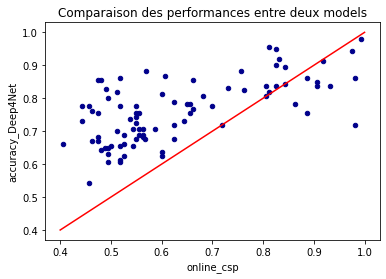

In [27]:
ax1 = accuracy.plot.scatter(x='online_csp',y='accuracy_Deep4Net', c='DarkBlue')
ax1.plot([0.4,1],[0.4,1], c="red")
ax1.set_title("Comparaison des performances entre deux models")

In [28]:

accuracy.corr()

,subject,accuracy_Deep4Net_0_4,accuracy_Deep4Net,online_csp
subject,1.000000,-0.151892,-0.000897,-0.041815
accuracy_Deep4Net_0_4,-0.151892,1.000000,0.380363,0.170270
accuracy_Deep4Net,-0.000897,0.380363,1.000000,0.648490
online_csp,-0.041815,0.170270,0.648490,1.000000


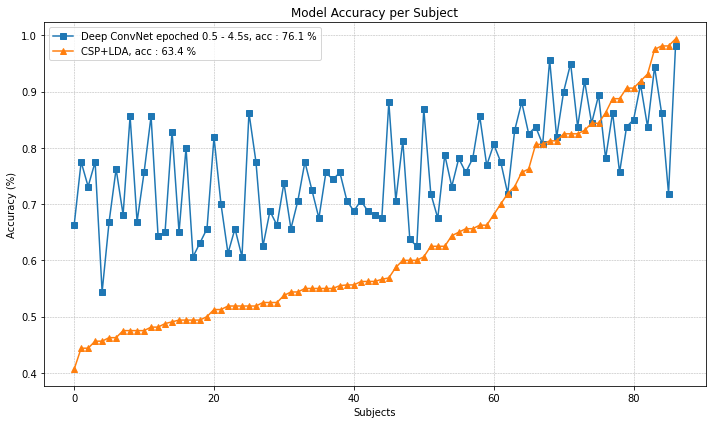

In [32]:
# Plot
accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-',label='Deep ConvNet epoched 0.5 - 4.5s, acc : {:.1f} %'.format(accuracy['accuracy_Deep4Net'].mean() * 100))
plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP+LDA, acc : {:.1f} %'.format(accuracy['online_csp'].mean() * 100))

plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

# plt.show()
# plt.savefig("bin/Figures/Deep_vs_csp_plot" , dpi =300 , pad_inches=3)

In [ ]:
accuracy_percent = accuracy * 100
print(accuracy_percent.mean())
print(accuracy_percent.std())

In [ ]:
(accuracy_percent>70).sum(axis=0)/len(accuracy_percent)

In [17]:
accuracy_percent[accuracy_percent['accuracy_Deep4Net'] < accuracy_percent['online_csp']]

,subject,accuracy_Deep4Net,accuracy_Deep4Net_logsquare,accuracy_FBCnet_varlayer,accuracy_Deep4Net_square,accuracy_FBCnet_log_var_layer,online_csp
64,7300,80.000,59.375,78.125,73.125,89.375,80.625
74,7000,80.000,61.250,60.000,78.125,73.125,86.250
76,4600,72.500,62.500,67.500,73.750,76.250,88.750
77,5900,83.125,59.375,86.875,77.500,88.125,90.625
78,2800,85.000,61.250,81.875,62.500,76.875,90.625
79,4900,91.250,80.000,79.375,83.750,91.875,91.875
80,1600,81.875,67.500,91.875,66.250,88.750,93.125
81,7600,93.125,75.000,91.875,85.625,94.375,97.500
82,2200,75.000,58.125,63.125,72.500,60.000,98.125
83,1000,83.125,58.750,86.250,76.250,84.375,98.125


In [18]:
accuracy_percent[accuracy_percent['online_csp'] >85].mean()

subject                          4000.000000
accuracy_Deep4Net                  84.715909
accuracy_Deep4Net_logsquare        66.875000
accuracy_FBCnet_varlayer           80.625000
accuracy_Deep4Net_square           77.670455
accuracy_FBCnet_log_var_layer      82.897727
online_csp                         93.011364
dtype: float64

In [19]:
accuracy_percent[accuracy_percent['online_csp'] >85].std()

subject                          2322.498654
accuracy_Deep4Net                   7.600183
accuracy_Deep4Net_logsquare         9.754807
accuracy_FBCnet_varlayer           12.698425
accuracy_Deep4Net_square            9.524192
accuracy_FBCnet_log_var_layer      11.135784
online_csp                          4.557087
dtype: float64

# Compare with square pooling 

C:\Users\dtrocell\AppData\Local\Temp\ipykernel_31864\862633959.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='blue', linestyle='dotted')
C:\Users\dtrocell\AppData\Local\Temp\ipykernel_31864\862633959.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(accuracy.index, accuracy.accuracy_Deep4Net_square, 's-', label='Deep ConvNet square', color='green', linestyle='dotted')
C:\Users\dtrocell\AppData\Local\Temp\ipykernel_31864\862633959.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(accuracy.index, accuracy.a

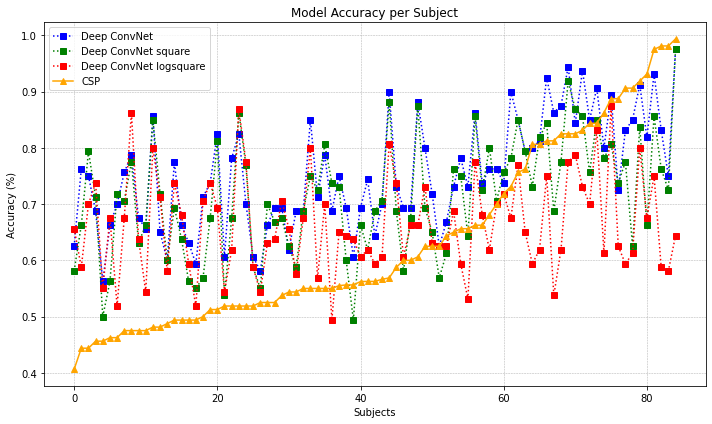

In [20]:
# Plot
accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='blue', linestyle='dotted')
plt.plot(accuracy.index, accuracy.accuracy_Deep4Net_square, 's-', label='Deep ConvNet square', color='green', linestyle='dotted')
plt.plot(accuracy.index, accuracy.accuracy_Deep4Net_logsquare, 's-', label='Deep ConvNet logsquare', color='red', linestyle='dotted')
plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')

plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.show()  

# Compare with FBCnet

C:\Users\dtrocell\AppData\Local\Temp\ipykernel_31864\490334294.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='blue', linestyle='dotted')
C:\Users\dtrocell\AppData\Local\Temp\ipykernel_31864\490334294.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(accuracy.index, accuracy.accuracy_FBCnet_varlayer, 's-', label='FBCnet_varlayer  ', color='yellow', linestyle='dotted')


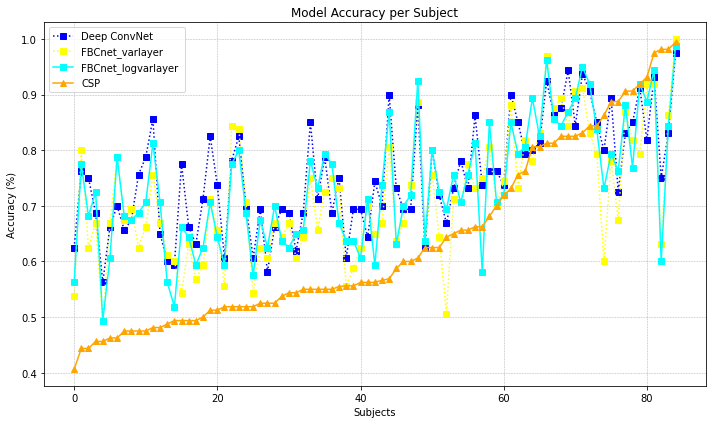

In [21]:
# Plot
accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='blue', linestyle='dotted')
plt.plot(accuracy.index, accuracy.accuracy_FBCnet_varlayer, 's-', label='FBCnet_varlayer  ', color='yellow', linestyle='dotted')
plt.plot(accuracy.index, accuracy.accuracy_FBCnet_log_var_layer , 's-', label='FBCnet_logvarlayer ', color='cyan')

plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')

plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Comparaison des performances entre deux models')

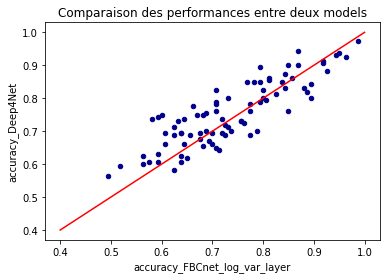

In [22]:
ax1 = accuracy.plot.scatter(x='accuracy_FBCnet_log_var_layer',y='accuracy_Deep4Net', c='DarkBlue')
ax1.plot([0.4,1],[0.4,1], c="red")
ax1.set_title("Comparaison des performances entre deux models")

In [23]:
accuracy_test = accuracy[['accuracy_FBCnet', 'accuracy_Deep4Net']]
accuracy_test.max(axis=1)

KeyError: "['accuracy_FBCnet'] not in index"

# Compare with 8-30 Hz

In [29]:
accuracy_8_30 = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out_simple_conv_8_30_Hz_0_5_4_5_s_.csv")
accuracy_8_30 = accuracy_8_30.sort_values("subject")
# accuracy = accuracy.sort_values("subject")  # Sort the index in order to be sure that the performances are correctly affected to the subject
accuracy_8_30.mean()   

subject              42.000000
accuracy_Deep4Net     0.675588
dtype: float64

In [30]:
accuracy

,accuracy,age,anxiety,anxiety_cat,accuracy_eegnet
0,40.625,25,6.8,"(4.533, 7.367]",0.52500
1,44.375,28,7.8,"(7.367, 10.2]",0.49375
2,45.625,40,4.1,"(1.692, 4.533]",0.52500
3,45.625,24,6.1,"(4.533, 7.367]",0.50000
4,46.250,30,8.1,"(7.367, 10.2]",0.69375
...,...,...,...,...,...
79,93.125,36,3.9,"(1.692, 4.533]",0.90625
80,97.500,27,3.1,"(1.692, 4.533]",0.88750
81,98.125,36,4.1,"(1.692, 4.533]",0.90000
82,98.125,52,4.2,"(1.692, 4.533]",0.59375


In [31]:
accuracy

,accuracy,age,anxiety,anxiety_cat,accuracy_eegnet
0,40.625,25,6.8,"(4.533, 7.367]",0.52500
1,44.375,28,7.8,"(7.367, 10.2]",0.49375
2,45.625,40,4.1,"(1.692, 4.533]",0.52500
3,45.625,24,6.1,"(4.533, 7.367]",0.50000
4,46.250,30,8.1,"(7.367, 10.2]",0.69375
...,...,...,...,...,...
79,93.125,36,3.9,"(1.692, 4.533]",0.90625
80,97.500,27,3.1,"(1.692, 4.533]",0.88750
81,98.125,36,4.1,"(1.692, 4.533]",0.90000
82,98.125,52,4.2,"(1.692, 4.533]",0.59375


In [32]:
accuracy_8_30

,subject,accuracy_Deep4Net
10,0,0.83750
0,1,0.93750
2,2,0.58750
1,3,0.53750
13,4,0.66250
...,...,...
76,80,0.85625
80,81,0.85625
83,82,0.76875
84,83,0.63750


In [ ]:

add_column(accuracy, "accuracy_Deep4Net_8_30", accuracy_8_30)


In [ ]:
accuracy 

In [ ]:
#plot

accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
# plt.plot(accuracy.index, accuracy.accuracy_SimpleConv, 'o-', label='SimpleConv', color='purple', linestyle='dashed')
plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='blue', linestyle='dotted')
plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')
plt.plot(accuracy.index, accuracy.accuracy_Deep4Net_8_30, 's-', label='Deep ConvNet_8_30', color='green', linestyle='dotted')
    
plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.show()

# Compare with no EA data

In [ ]:
accuracy_no_EA = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out_simple_conv_normalization.csv")
accuracy_no_EA = accuracy_no_EA[0:85]

In [ ]:
accuracy_no_EA = accuracy_no_EA.sort_values("subject")
accuracy_no_EA

In [ ]:
accuracy_EA_8_30 = pd.read_csv(
    "../../../../Results/DL_accuracy/accuracies_leave_one_out_simple_conv_8_30_normalized.csv")
accuracy_8_30 = accuracy_8_30.sort_values("subject")
accuracy_8_30

In [ ]:

add_column(accuracy, "simple_conv_no_EA", accuracy_no_EA, "accuracy_SimpleConv")
add_column(accuracy, "simple_conv_8_30", accuracy_EA_8_30, "accuracy_SimpleConv")
add_column(accuracy, "deep_conv_no_EA", accuracy_no_EA, "accuracy_Deep4Net")
add_column(accuracy, "deep_conv_8_30", accuracy_EA_8_30, "accuracy_Deep4Net")


In [ ]:
accuracy.mean()

In [ ]:
# Plot

accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
# plt.plot(accuracy.index, accuracy.accuracy_SimpleConv, 'o-', label='SimpleConv', color='purple', linestyle='dashed')
plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='red', linestyle='dotted')
plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')
# plt.plot(accuracy.index, accuracy.simple_conv_no_EA, 'o-', label='SimpleConv_no_EA', color='blue')
# plt.plot(accuracy.index, accuracy.simple_conv_8_30, 'o-', label='SimpleConv_8_30', color='yellow', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.deep_conv_no_EA, 's-', label='Deep ConvNet_no_EA', color='grey')
plt.plot(accuracy.index, accuracy.deep_conv_8_30, 's-', label='Deep ConvNet_8_30', color='green', linestyle='dotted')

plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()


# Compared with previous results

In [ ]:
accuracy_bad = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out.csv")
accuracy_bad = accuracy_bad.set_index("subject")
accuracy_bad = accuracy_bad[0:85]
accuracy_bad["subject"] = range(len(offline_order))




In [ ]:
accuracy_bad

In [ ]:

add_column(accuracy, "deep_conv_bad", accuracy_bad, "accuracy_deepConvNet")
accuracy.mean()

In [ ]:
#plot
accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
# plt.plot(accuracy.index, accuracy.accuracy_SimpleConv, 'o-', label='SimpleConv', color='purple', linestyle='dashed')
plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='red', linestyle='dotted')
plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')
plt.plot(accuracy.index, accuracy.deep_conv_bad, 's-', label='Deep ConvNet_bad', color='black', linestyle='dotted')

plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()


# Compare with 0.5-4.5 epoching window

In [ ]:
accuracy_0_5_4_5 = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out_simple_conv_0_5__4_5.csv")

accuracy_0_5_4_5.mean()

In [ ]:
accuracy_0_5_4_5_EA = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out_simple_conv_normalized_0_5__4_5.csv")

accuracy_0_5_4_5_EA.mean()

In [ ]:
add_column(accuracy, "simple_conv_0_5_4_5", accuracy_0_5_4_5, "accuracy_SimpleConv")
add_column(accuracy, "simple_conv_0_5_4_5_EA", accuracy_0_5_4_5_EA , "accuracy_SimpleConv")
add_column(accuracy, "deep_conv_0_5_4_5", accuracy_0_5_4_5, "accuracy_Deep4Net")
add_column(accuracy, "deep_conv_0_5_4_5_EA", accuracy_0_5_4_5_EA, "accuracy_Deep4Net")
accuracy.mean()

In [ ]:
#plot

accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
# plt.plot(accuracy.index, accuracy.accuracy_SimpleConv, 'o-', label='SimpleConv', color='purple', linestyle='dashed')
# plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='red', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.deep_conv_8_30, 's-', label='Deep ConvNet no EA', color='grey')

plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')
plt.plot(accuracy.index, accuracy.deep_conv_0_5_4_5, 's-', label='Deep ConvNet [0.5-4.5s] no EA', color='black', linestyle='dotted')
plt.plot(accuracy.index, accuracy.deep_conv_0_5_4_5_EA, 's-', label='Deep ConvNet[0.5-4.5s] with EA', color='cyan', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.simple_conv_0_5_4_5, 'o-', label='SimpleConv_0_5_4_5', color='blue', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.simple_conv_0_5_4_5_EA, 'o-', label='SimpleConv_0_5_4_5_EA', color='yellow', linestyle='dotted')

plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()


# Remove frontal channels

In [ ]:
accuracy_no_frontal = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out_simple_conv_0_5__255_Hz_no_frontal.csv")
# accuracy_no_frontal = accuracy_no_frontal.set_index("subject")
accuracy_no_frontal.mean()

In [ ]:
accuracy["deep_conv_no_frontal"] = accuracy_no_frontal["accuracy_Deep4Net"]
add_column(accuracy, "deep_conv_no_frontal", accuracy_no_frontal, "accuracy_Deep4Net")
accuracy.mean()

In [ ]:
#plot

accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
# plt.plot(accuracy.index, accuracy.accuracy_SimpleConv, 'o-', label='SimpleConv', color='purple', linestyle='dashed')
plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='red', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.deep_conv_8_30, 's-', label='Deep ConvNet no EA', color='grey')

plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')
# plt.plot(accuracy.index, accuracy.deep_conv_0_5_4_5, 's-', label='Deep ConvNet [0.5-4.5s] no EA', color='black')
plt.plot(accuracy.index, accuracy.deep_conv_0_5_4_5_EA, 's-', label='Deep ConvNet[0.5-4.5s] with EA', color='cyan')
plt.plot(accuracy.index, accuracy.deep_conv_no_frontal, 's-', label='Deep ConvNet no frontal', color='olive')
# plt.plot(accuracy.index, accuracy.simple_conv_0_5_4_5, 'o-', label='SimpleConv_0_5_4_5', color='blue', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.simple_conv_0_5_4_5_EA, 'o-', label='SimpleConv_0_5_4_5_EA', color='yellow', linestyle='dotted')


plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()





# Remove frontal channels and without EA

In [ ]:
accuracy_no_frontal_no_EA = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out_simple_conv_0_5__255_Hz_no_frontal_no_EA.csv")
accuracy_no_frontal_no_EA = accuracy_no_frontal_no_EA.set_index("subject")
accuracy_no_frontal_no_EA = accuracy_no_frontal_no_EA.sort_index()
accuracy_no_frontal_no_EA.mean()

In [ ]:
accuracy["deep_conv_no_frontal_no_EA"] = accuracy_no_frontal_no_EA["accuracy_Deep4Net"]
accuracy.mean()

In [ ]:
#plot

accuracy = accuracy.sort_values(by='online_csp', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
# plt.plot(accuracy.index, accuracy.accuracy_SimpleConv, 'o-', label='SimpleConv', color='purple', linestyle='dashed')
# plt.plot(accuracy.index, accuracy.accuracy_Deep4Net, 's-', label='Deep ConvNet', color='red', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.deep_conv_8_30, 's-', label='Deep ConvNet no EA', color='grey')
plt.plot(accuracy.index, accuracy.deep_conv_8_30, 's-', label='Deep ConvNet no EA', color='grey')

plt.plot(accuracy.index, accuracy.online_csp, '^-', label='CSP', color='orange')
plt.plot(accuracy.index, accuracy.deep_conv_0_5_4_5, 's-', label='Deep ConvNet [0.5-4.5s] no EA', color='black')
# plt.plot(accuracy.index, accuracy.deep_conv_0_5_4_5_EA, 's-', label='Deep ConvNet[0.5-4.5s] with EA', color='cyan')
# plt.plot(accuracy.index, accuracy.deep_conv_no_frontal, 's-', label='Deep ConvNet no frontal', color='olive')
plt.plot(accuracy.index, accuracy.deep_conv_no_frontal_no_EA, 's-', label='Deep ConvNet no frontal no EA', color='purple')
# plt.plot(accuracy.index, accuracy.simple_conv_0_5_4_5, 'o-', label='SimpleConv_0_5_4_5', color='blue', linestyle='dotted')
# plt.plot(accuracy.index, accuracy.simple_conv_0_5_4_5_EA, 'o-', label='SimpleConv_0_5_4_5_EA', color='yellow', linestyle='dotted')


plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()



# Compared with Keras

In [ ]:
accuracy_1s = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out_batch_512.csv")
accuracy_1s = accuracy_1s.set_index("subject")
accuracy_1s = accuracy_1s.drop("C83") # C83 is not in the keras results

In [ ]:
accuracy_2s = pd.read_csv("../../../../Results/DL_accuracy/accuracies_leave_one_out.csv")
# accuracy_2s
accuracy_2s = accuracy_2s.set_index("subject")
accuracy_2s = accuracy_2s.drop("C83") # C83 is not in the keras results

In [ ]:
accuracy_2s

In [24]:
accuracy_keras = pd.read_csv("../../../../Results/DL_accuracy/ACC_Leave_one_out_Keras.csv" , index_col=0)
# accuracy_keras = accuracy_keras.set_index("subject")

In [25]:
accuracy_keras["accuracy_eegnet_1S"] = accuracy_1s["accuracy_EEGNet"] *100
accuracy_keras["accuracy_deep4net_1S"] = accuracy_1s["accuracy_Deep4Net"] *100
accuracy_keras["accuracy_deep4net_2S"] = accuracy_2s["accuracy_Deep4Net"] *100
accuracy_keras["accuracy_eegnet_1S_keras"] = accuracy_keras["accuracy_eegnet"] *100

NameError: name 'accuracy_1s' is not defined

In [ ]:
accuracy_keras = accuracy_keras.drop("A37") # A37 is equal to 0 in the keras results

In [26]:
accuracy_keras

,accuracy,age,anxiety,anxiety_cat,accuracy_eegnet
A1,84.375,28,9.1,"(7.367, 10.2]",0.70625
A2,55.625,28,4.7,"(4.533, 7.367]",0.58750
A3,98.125,52,4.2,"(1.692, 4.533]",0.59375
A4,51.250,39,6.8,"(4.533, 7.367]",0.63125
A5,51.250,36,6.4,"(4.533, 7.367]",0.57500
...,...,...,...,...,...
C82,49.375,26,3.0,"(1.692, 4.533]",0.49375
C84,76.250,20,6.0,"(4.533, 7.367]",0.76875
C85,80.625,30,9.0,"(7.367, 10.2]",0.70000
C86,62.500,21,6.1,"(4.533, 7.367]",0.65000


In [27]:
# Plot
accuracy = accuracy_keras.sort_values(by='accuracy', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.plot(accuracy_keras.index, accuracy_keras.accuracy_eegnet_1S, 'o-', label='EEGNEt_tensorflow_1S', color='purple', linestyle='dashed')
plt.plot(accuracy_keras.index, accuracy_keras.accuracy_deep4net_1S, 's-', label='Deep ConvNet_tensorflow_1S', color='blue', linestyle='dotted')
plt.plot(accuracy_keras.index, accuracy_keras.accuracy_deep4net_2S, 's-', label='Deep ConvNet_tensorflow_2S', color='blue')
plt.plot(accuracy_keras.index, accuracy_keras.accuracy_eegnet_1S_keras, '^-', label='EEGNetKeras', color='red')
plt.plot(accuracy.index, accuracy.accuracy, '^-', label='CSP', color='orange')

plt.xlabel('Subjects')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy per Subject')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.show()

AttributeError: 'DataFrame' object has no attribute 'accuracy_eegnet_1S'

<Figure size 720x432 with 0 Axes>

In [ ]:
accuracy_keras.mean()

# Compare with square pooling 